In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

import pyswarms as ps
from deap import base, creator, tools, algorithms
import random

In [6]:
df = pd.read_csv("cleandata.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

series = df['demand_kWh']

series = series.asfreq('h')
series = series.ffill()

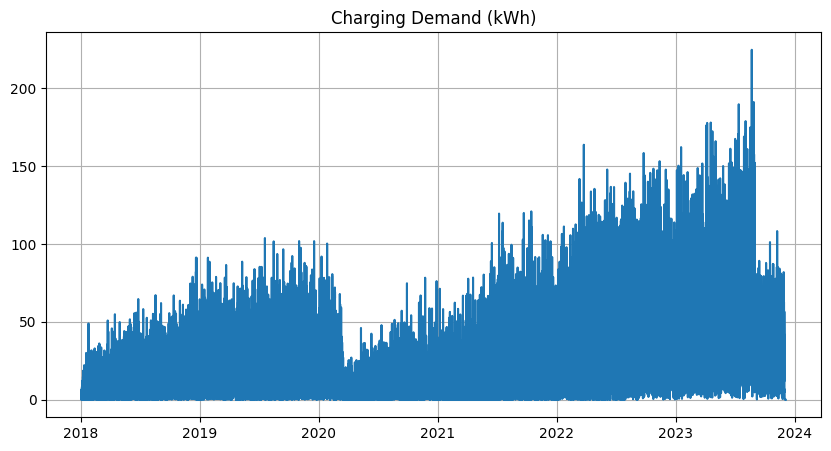

In [7]:
# Plot raw data
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Charging Demand (kWh)")
plt.grid()
plt.show()

In [8]:
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

In [10]:
#SARIMA
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_fit = sarima_model.fit(method='powell', maxiter=200, disp=False, 
                        low_memory=True, conserve_memory=True)

sarima_pred = sarima_fit.forecast(steps=len(test))

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: conserve_memory. After release 0.14, this will raise.
  warnings.warn(


In [11]:
#PREPARE DATA FOR TCN
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X, y = create_sequences(scaled, window)
X_train, X_test = X[:train_size-window], X[train_size-window:]
y_train, y_test = y[:train_size-window], y[train_size-window:]

y_test_inv = scaler.inverse_transform(y_test)

In [12]:
#BUILD TCN
def build_tcn(filters=64, kernel_size=3, dropout=0.2):
    model = Sequential([
        TCN(filters, kernel_size=kernel_size, dropout_rate=dropout, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [13]:
#TCN MODEL
tcn_model = build_tcn()
history_tcn = tcn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

tcn_pred = scaler.inverse_transform(tcn_model.predict(X_test))

2026-03-31 16:01:43,595 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Epoch 1/10



2026-03-31 16:01:44,736 - tensorflow - WARNING - From C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\backend\tensorflow\core.py:232: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.



1038/1038 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - loss: 0.0435 - val_loss: 0.0036
Epoch 2/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 0.0023 - val_loss: 0.0044
Epoch 3/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 4/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 0.0016 - val_loss: 0.0046
Epoch 5/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 0.0016 - val_loss: 0.0041
Epoch 6/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 0.0015 - val_loss: 0.0036
Epoch 7/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0015 - val_loss: 0.0040
Epoch 8/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 9/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 0.0014 - val_loss: 0.0031
Epoch 10/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 0.0014 - val_loss: 0.0034
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [14]:
#PSO-TCN
def fitness_function(params):
    errors = []
    for p in params:
        model = build_tcn(int(p[0]), int(p[1]), float(p[2]))
        model.fit(X_train, y_train, epochs=5, verbose=0)

        pred = scaler.inverse_transform(model.predict(X_test))
        error = np.mean((pred - y_test_inv)**2)
        errors.append(error)
    return np.array(errors)

bounds = ([32, 2, 0.1], [128, 5, 0.5])

optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1':0.5,'c2':0.3,'w':0.9},
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(fitness_function, iters=5)

pso_model = build_tcn(int(best_pos[0]), int(best_pos[1]), best_pos[2])
history_pso = pso_model.fit(X_train, y_train, epochs=20, validation_split=0.2)

pso_pred = scaler.inverse_transform(pso_model.predict(X_test))

2026-03-31 16:05:46,014 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                 |0/5

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


pyswarms.single.global_best:  20%|█████████████▏                                                    |1/5, best_cost=179

325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


pyswarms.single.global_best:  40%|██████████████████████████▍                                       |2/5, best_cost=179

...

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


pyswarms.single.global_best:  80%|████████████████████████████████████████████████████▊             |4/5, best_cost=179

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


pyswarms.single.global_best: 100%|██████████████████████████████████████████████████████████████████|5/5, best_cost=179
2026-03-31 17:01:52,073 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 178.9242244786789, best pos: [50.6993151   3.79194496  0.16588769]


Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 0.0067 - val_loss: 0.0037
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0016 - val_loss: 0.0039
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0015 - val_loss: 0.0032
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0014 - val_loss: 0.0040
Epoch 11/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 12

In [16]:
#GA-TCN
from deap import base, creator, tools, algorithms

if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def eval_individual(ind):
    filters = int(ind[0])
    kernel = int(ind[1])
    dropout = float(ind[2])

    model = build_tcn(filters, kernel, dropout)
    model.fit(X_train, y_train, epochs=5, verbose=0)

    pred = scaler.inverse_transform(model.predict(X_test))
    return (np.mean((pred - y_test_inv)**2),)

toolbox = base.Toolbox()

toolbox.register("attr_filters", random.randint, 32, 128)
toolbox.register("attr_kernel", random.randint, 2, 5)
toolbox.register("attr_dropout", random.uniform, 0.1, 0.5)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_filters, toolbox.attr_kernel, toolbox.attr_dropout), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)

def mutate_individual(ind):
    ind[0] = int(np.clip(ind[0] + random.randint(-10, 10), 32, 128))
    ind[1] = int(np.clip(ind[1] + random.randint(-1, 1), 2, 5))
    ind[2] = float(np.clip(ind[2] + random.uniform(-0.1, 0.1), 0.1, 0.5))
    return (ind,)

toolbox.register("mutate", mutate_individual)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)

pop, logbook = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=5,
    verbose=True
)

best_ind = tools.selBest(pop, 1)[0]
print("GA Best:", best_ind)

ga_model = build_tcn(int(best_ind[0]), int(best_ind[1]), float(best_ind[2]))
history_ga = ga_model.fit(X_train, y_train, epochs=20, validation_split=0.2)

ga_pred = scaler.inverse_transform(ga_model.predict(X_test))

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
gen	nevals
0  	5     
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
1  	4     
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
2  	4     
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
3  	4     
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
4  	4     
5  	0     
GA Best: [111.00000000000001, 4.0, 0.126917993

In [17]:
#METRICS
def metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

m_sarima = metrics(test.values, sarima_pred.values)
m_tcn = metrics(y_test_inv.flatten(), tcn_pred.flatten())
m_pso = metrics(y_test_inv.flatten(), pso_pred.flatten())
m_ga = metrics(y_test_inv.flatten(), ga_pred.flatten())

In [18]:
#RESIDUALS
res_sarima = test.values - sarima_pred.values
res_tcn = y_test_inv.flatten() - tcn_pred.flatten()
res_pso = y_test_inv.flatten() - pso_pred.flatten()
res_ga = y_test_inv.flatten() - ga_pred.flatten()

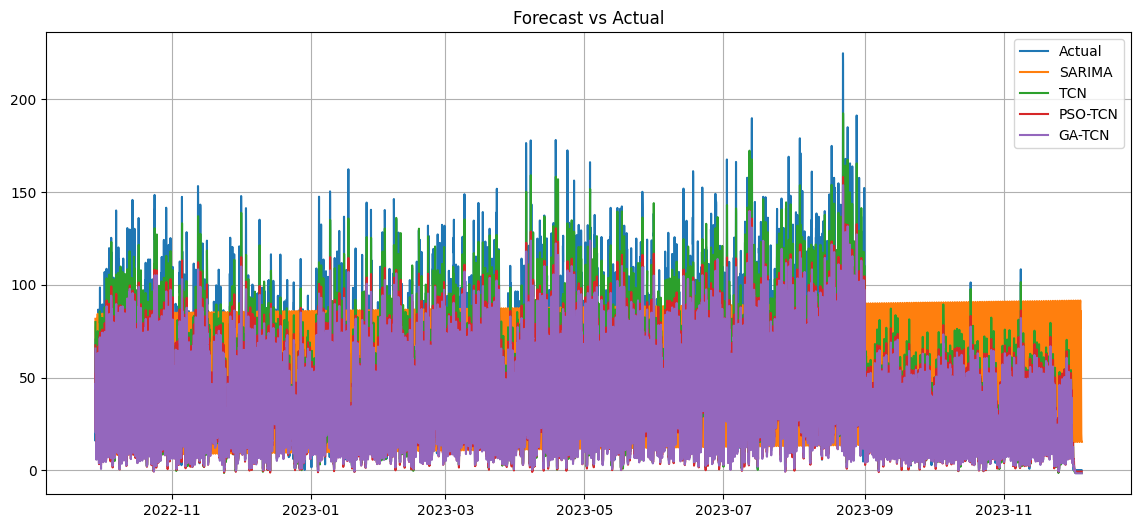

In [19]:
#KEY PLOTS
#Forecast vs Actual
plt.figure(figsize=(14,6))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, sarima_pred.values, label='SARIMA')
plt.plot(test.index[-len(tcn_pred):], tcn_pred, label='TCN')
plt.plot(test.index[-len(pso_pred):], pso_pred, label='PSO-TCN')
plt.plot(test.index[-len(ga_pred):], ga_pred, label='GA-TCN')
plt.legend(); plt.title("Forecast vs Actual"); plt.grid(); plt.show()

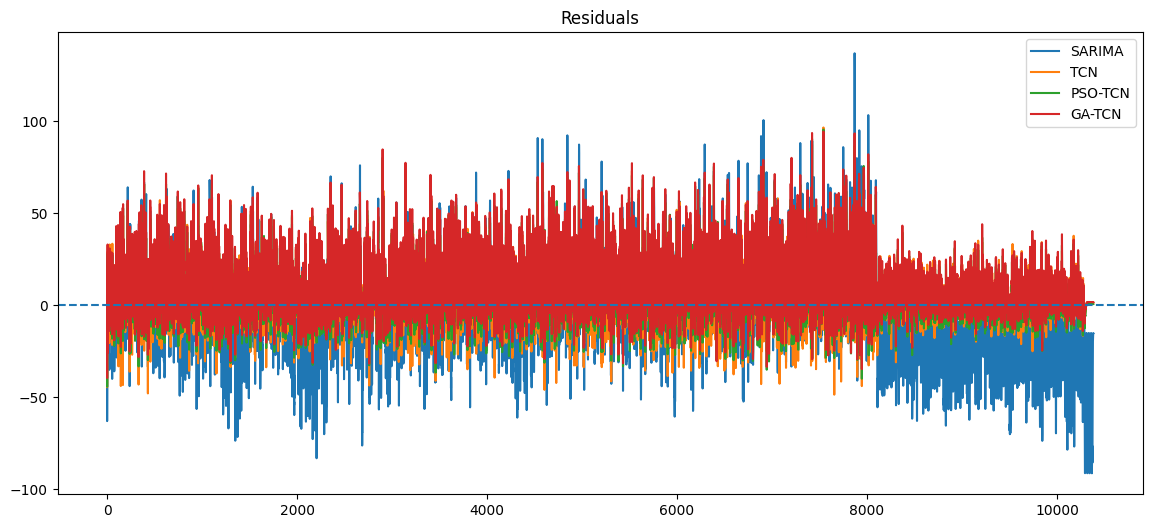

In [20]:
#Residual Plot
plt.figure(figsize=(14,6))
plt.plot(res_sarima, label='SARIMA')
plt.plot(res_tcn, label='TCN')
plt.plot(res_pso, label='PSO-TCN')
plt.plot(res_ga, label='GA-TCN')
plt.axhline(0, linestyle='--')
plt.legend(); plt.title("Residuals"); plt.show()

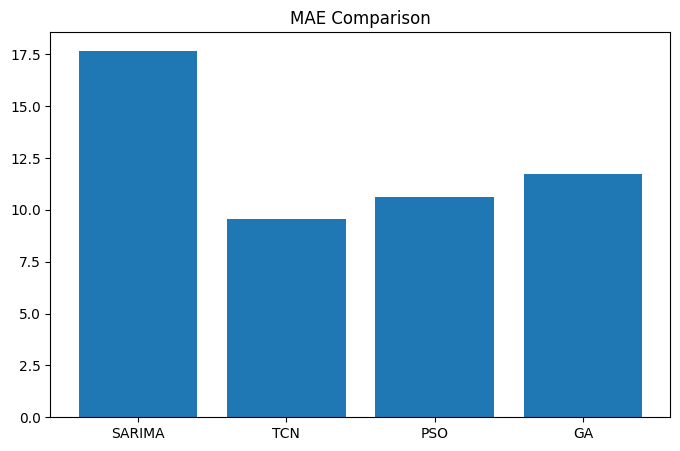

In [21]:
#Error Metrics Bar Chart
labels = ['SARIMA','TCN','PSO','GA']
mae_vals = [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]]

plt.figure(figsize=(8,5))
plt.bar(labels, mae_vals)
plt.title("MAE Comparison")
plt.show()